In [3]:

from pathlib import Path
import argparse
import numpy as np
import sys

sys.path.append(r"/users/jpm590/2dspace/post-processing/sdtools")

from hermes3.case_db import *
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *

%matplotlib widget


## Plot puff location

Mesh file /users/jpm590/gridfile/CDN_46895_260401_asym_puff.nc closed


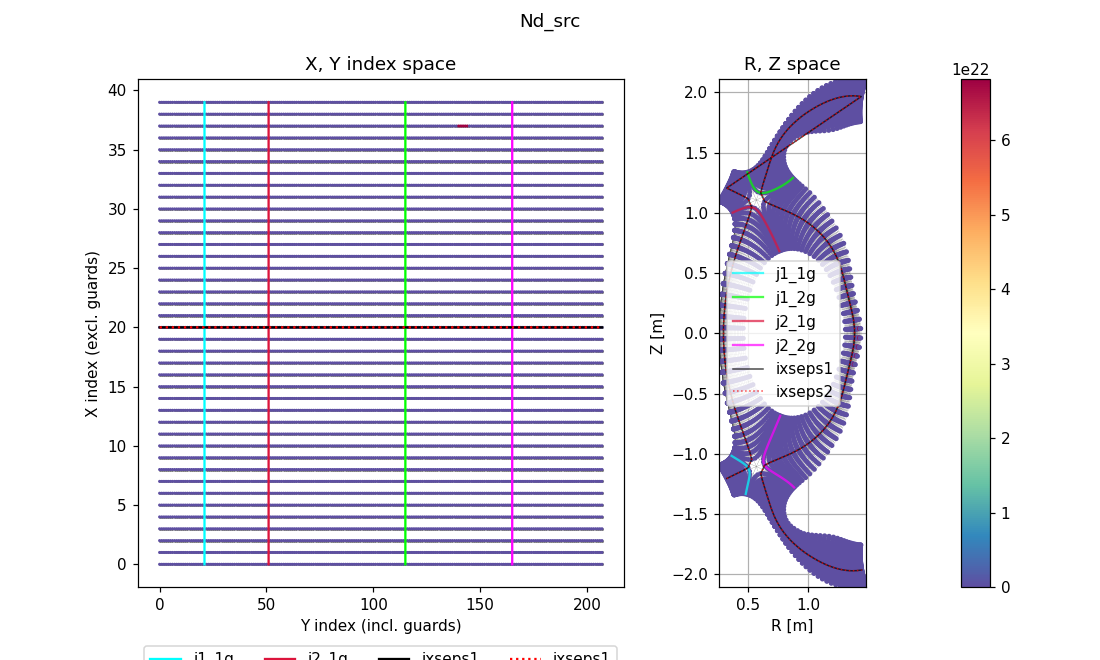

In [5]:

# 1. Load the grid (.nc file)
mesh = Mesh("/users/jpm590/gridfile/CDN_46895_260401_asym_puff.nc")
# mesh = Mesh("/users/jpm590/neutralimit_gcc12_9497476/hermes-3/build-mc-master/CDN_46895_260314_nowallpump_3e20.nc")
# 2. Plot the existing fields in the mesh
mesh.plot_field("Nd_src")
# mesh.plot_field("Pd_src")
# mesh.plot_field("Nd+_src")
# 3. Always remember to close it!
mesh.close()
plt.show()



In the original notebbok from Mike, it was 
```
    Ni_src_core = 0,    # s-1
    Pi_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
    Pe_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
```
You can see he mean to convert 0.3 MW into Pascal, but then he put it into zero because he can assign the power_in for e and ion in the `BOUT.inp` 

In [ ]:
old_grid_path = r"/users/jpm590/neutralimit_gcc12_9497476/hermes-3/build-mc-master/CDN_46895_260314_nowallpump_3e20.nc"
new_grid_path = r"/users/jpm590/test.nc"
impose_fields(
    old_grid_path,
    new_grid_path,
    Nd_src_puff = 1.3e21,
    Ni_src_core = 0,    # s-1
    Pi_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
    Pe_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
    D_core = 4,
    chi_core = 10,
    D_sol = 4,
    chi_sol = 4,
)

# Run with NetCDF file

In [6]:
from scipy.io import netcdf
import netCDF4 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

filepath = "/users/jpm590/neutralrun/hermes-3/master/CDN_46895_260120_nowallpump_2e21.nc"
nc = netCDF4.Dataset(filepath)
list(nc.variables.keys() )

['nx',
 'ny',
 'y_boundary_guards',
 'curvature_type',
 'Bt_axis',
 'psi_axis',
 'psi_bdry',
 'psi_axis_gfile',
 'psi_bdry_gfile',
 'closed_wall_R',
 'closed_wall_Z',
 'Rxy',
 'Rxy_xlow',
 'Rxy_ylow',
 'Zxy',
 'Zxy_xlow',
 'Zxy_ylow',
 'psixy',
 'psixy_xlow',
 'psixy_ylow',
 'dx',
 'dx_xlow',
 'dx_ylow',
 'dy',
 'dy_xlow',
 'dy_ylow',
 'poloidal_distance',
 'poloidal_distance_xlow',
 'poloidal_distance_ylow',
 'parallel_distance',
 'parallel_distance_xlow',
 'parallel_distance_ylow',
 'Brxy',
 'Brxy_xlow',
 'Brxy_ylow',
 'Bzxy',
 'Bzxy_xlow',
 'Bzxy_ylow',
 'Bpxy',
 'Bpxy_xlow',
 'Bpxy_ylow',
 'Btxy',
 'Btxy_xlow',
 'Btxy_ylow',
 'Bxy',
 'Bxy_xlow',
 'Bxy_ylow',
 'hy',
 'hy_xlow',
 'hy_ylow',
 'dphidy',
 'dphidy_xlow',
 'dphidy_ylow',
 'ShiftTorsion',
 'ShiftTorsion_xlow',
 'ShiftTorsion_ylow',
 'zShift',
 'zShift_xlow',
 'zShift_ylow',
 'g11',
 'g11_xlow',
 'g11_ylow',
 'g22',
 'g22_xlow',
 'g22_ylow',
 'g33',
 'g33_xlow',
 'g33_ylow',
 'g12',
 'g12_xlow',
 'g12_ylow',
 'g13',
 'g13_x

In [7]:
print(nc["D_d+"])
print(nc["is_pump"][39::])


<class 'netCDF4.Variable'>
float64 D_d+(x, y)
    bout_type: Field2D
unlimited dimensions: 
current shape = (40, 208)
filling on, default _FillValue of 9.969209968386869e+36 used
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


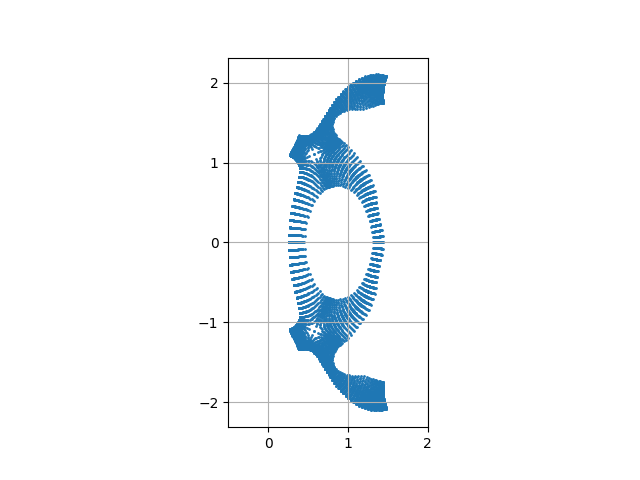

In [8]:
fig, ax = plt.subplots()
n=1
m=3
k=1
# Rxy = nc.variables['Rxy'][n:m:k]
Rxy = nc.variables['Rxy_lower_right_corners'][:]
Zxy = nc.variables['Zxy_lower_right_corners'][:]


# print(f"Rxy: {Rxy}")
# Zxy = nc.variables['Zxy'][n:m:k]

# print(f"Zxy: {Zxy}")

ax.scatter(Rxy, Zxy, s=1)
ax.set_xlim(-0.5, 2.0)
# ax.set_ylim(0.0, 2.0)
ax.set_aspect('equal', adjustable='box')
ax.grid()